In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src import config as cfg

df = pd.read_csv(cfg.DATA_CLEAN, encoding=cfg.ENCODING)
print(df.shape)
df.head(3)

(1247, 40)


,timestamp,age,gender,country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,employment_type,size_rank,leave_score,interfere_score,knows_leave_policy,age_group,has_comment,survey_wave,uncertainty_score,support_score
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Unknown,2,3.0,4.0,Yes,35-44,No,Main,1,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Unknown,6,NaN,2.0,No,35-44,No,Main,6,NaN
2,2014-08-27 11:29:44,32,Male,Canada,Not applicable,NaN,No,No,Rarely,6-25,...,Unknown,2,2.0,2.0,Yes,25-34,No,Main,1,NaN


In [2]:
# ---- House style for every chart in this notebook ----
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GREY, INK = "#9a9a95", "#0b0b0b"

# Colour by meaning, fixed everywhere, so a colour never changes job mid-notebook
C_YES, C_NO, C_UNSURE = BLUE, GREY, ORANGE

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#e6e6e3",
    "grid.linewidth": 0.8,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelcolor": "#52514e",
    "text.color": INK,
    "font.size": 10,
})
sns.set_style("whitegrid", {"grid.color": "#e6e6e3"})

FIGDIR = cfg.FIGURES_DIR
FIGDIR.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    """Save a figure to reports/figures so the report and slides can reuse it."""
    fig.savefig(FIGDIR / f"{name}.png")
    print(f"saved {name}.png")

def pct_labels(ax, fmt="{:.1f}%", pad=1):
    """Write the value on each bar - required because colour alone is not enough."""
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt.format, padding=pad, color="#52514e", fontsize=9)

print("style ready")

style ready


# Mental Health in Tech Survey — EDA

Data: `data/processed/survey_clean.csv` — 1,247 respondents, 40 columns.
Cleaning decisions: `docs/cleaning_decision_log.md`.

Two denominators are used throughout:
**1,247** for everything, **1,088 employees** for the six employer-support questions
(self-employed respondents have no employer — DQ-14).

## 1. Who answered

Before any finding, we establish who this sample is — and who it is not.

In [3]:
n = len(df)

profile = pd.DataFrame({
    "Measure": [
        "Respondents",
        "Median age (range)",
        "Male / Female / Gender-diverse",
        "United States",
        "Work at a tech company",
        "Work remotely >= 50%",
        "Employees (have an employer)",
    ],
    "Value": [
        f"{n:,}",
        f"{df.age.median():.0f} ({df.age.min():.0f}-{df.age.max():.0f})",
        f"{(df.gender_clean=='Male').mean():.1%} / {(df.gender_clean=='Female').mean():.1%} / {(df.gender_clean=='Gender-diverse').mean():.1%}",
        f"{(df.country=='United States').mean():.1%}",
        f"{(df.tech_company=='Yes').mean():.1%}",
        f"{(df.remote_work=='Yes').mean():.1%}",
        f"{(df.employment_type=='Employee').sum():,}",
    ],
})
profile

,Measure,Value
0,Respondents,"1,247"
1,Median age (range),31 (18-72)
2,Male / Female / Gender-diverse,79.1% / 19.8% / 1.0%
3,United States,59.8%
4,Work at a tech company,82.0%
5,Work remotely >= 50%,29.8%
6,Employees (have an employer),"1,088"


## 2. How common is it, and who gets help?

`has_condition` is derived from the work-interference question (DQ-05).
`treatment` means the person has sought treatment at some point — it is not a
measure of current illness (DQ-25).

In [4]:
ct = pd.crosstab(df.has_condition, df.treatment)
ct_pct = (ct / len(df) * 100).round(1)
print(ct, "\n")

with_cond = ct.loc["Yes"].sum()
treated = ct.loc["Yes", "Yes"]
untreated = ct.loc["Yes", "No"]
print(f"Have a condition:            {with_cond:,} ({with_cond/len(df):.1%})")
print(f"  ...and sought treatment:   {treated:,} ({treated/with_cond:.1%} of them)")
print(f"  ...and never sought help:   {untreated:,} ({untreated/len(df):.1%} of everyone)")

treatment       No  Yes
has_condition          
No             257    4
Yes            360  626 

Have a condition:            986 (79.1%)
  ...and sought treatment:   626 (63.5% of them)
  ...and never sought help:   360 (28.9% of everyone)


saved 02_condition_vs_treatment.png


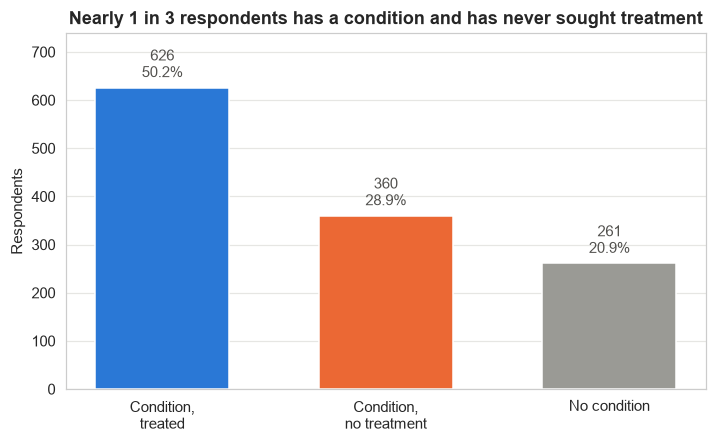

In [5]:
groups = ["Condition,\ntreated", "Condition,\nno treatment", "No condition"]
values = [treated, untreated, (df.has_condition == "No").sum()]
colors = [BLUE, ORANGE, GREY]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.bar(groups, values, color=colors, width=0.6)
ax.bar_label(bars, labels=[f"{v:,}\n{v/len(df):.1%}" for v in values],
             padding=4, color="#52514e", fontsize=10)
ax.set_ylim(0, max(values) * 1.18)
ax.set_ylabel("Respondents")
ax.set_title("Nearly 1 in 3 respondents has a condition and has never sought treatment")
ax.grid(axis="x", visible=False)
save(fig, "02_condition_vs_treatment")
plt.show()

### 2.1 Among those with a condition, what separates the 626 from the 360?

All figures below are within the 986 respondents who report a condition, so the
comparison is like-for-like: everyone in this group has a reason to seek help.

saved 03_who_gets_help.png


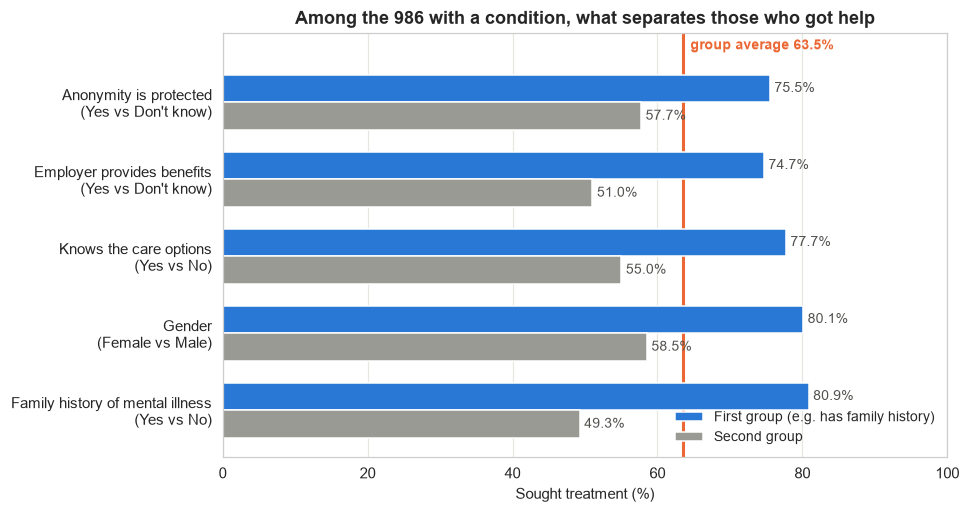

In [9]:
cond = df[df.has_condition == "Yes"].copy()
cond["treated"] = cond.treatment.eq("Yes")

factors = [
    ("Family history of mental illness", "family_history", "Yes", "No"),
    ("Gender", "gender_clean", "Female", "Male"),
    ("Knows the care options", "care_options", "Yes", "No"),
    ("Employer provides benefits", "benefits", "Yes", "Don't know"),
    ("Anonymity is protected", "anonymity", "Yes", "Don't know"),
]

rows = []
for label, col, hi, lo in factors:
    for level, tag in [(hi, "higher"), (lo, "lower")]:
        sub = cond[cond[col] == level]
        rows.append({"factor": label, "level": tag,
                     "rate": sub.treated.mean() * 100, "n": len(sub)})
comp = pd.DataFrame(rows)

y = np.arange(len(factors)); h = 0.36
fig, ax = plt.subplots(figsize=(8.5, 5))
b1 = ax.barh(y + h/2, comp[comp.level == "higher"].rate, height=h, color=BLUE,
             label="First group (e.g. has family history)")
b2 = ax.barh(y - h/2, comp[comp.level == "lower"].rate, height=h, color=GREY,
             label="Second group")
ax.bar_label(b1, fmt="%.1f%%", padding=3, fontsize=9, color="#52514e")
ax.bar_label(b2, fmt="%.1f%%", padding=3, fontsize=9, color="#52514e")
avg = cond.treated.mean() * 100
ax.axvline(avg, color=ORANGE, linewidth=2, zorder=0)
ax.set_ylim(-0.6, len(factors) - 0.1)
ax.annotate(f"group average {avg:.1f}%",
            xy=(avg, 0.985), xycoords=("data", "axes fraction"),
            xytext=(5, 0), textcoords="offset points",
            color=ORANGE, fontsize=9, fontweight="bold", ha="left", va="top")

ax.set_yticks(y, [f"{lab}\n({hi} vs {lo})" for lab, _, hi, lo in factors])
ax.set_xlim(0, 100)
ax.set_xlabel("Sought treatment (%)")
ax.set_title("Among the 986 with a condition, what separates those who got help")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right", frameon=False, fontsize=9)
save(fig, "03_who_gets_help")
plt.show()

In [8]:
from scipy import stats

print(f"{'Factor':<28}{'chi2':>8}{'p-value':>12}")
for label, col, *_ in factors:
    table = pd.crosstab(cond[col], cond.treated)
    chi2, p, dof, _ = stats.chi2_contingency(table)
    print(f"{label:<28}{chi2:>8.1f}{p:>12.2e}")

Factor                          chi2     p-value
Family history of mental illness   103.7    2.31e-24
Gender                          35.7    1.78e-08
Knows the care options          55.6    8.39e-13
Employer provides benefits      42.6    5.61e-10
Anonymity is protected          27.7    9.79e-07


## 3. Does location matter?

Reporting rule (DQ-24): no country is charted below **n = 20**; the remaining 39
countries are grouped as "Other". Error bars are 95% Wilson intervals — the range
the true rate plausibly sits in given the sample size.

saved 04_country_treatment.png


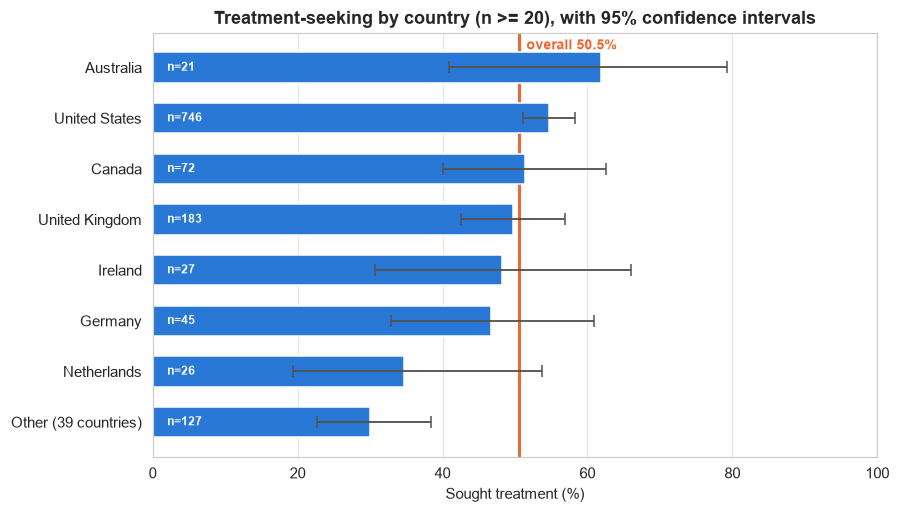

,n,k,rate,lo,hi
country,,,,,
Other (39 countries),127,38,29.9,22.6,38.4
Netherlands,26,9,34.6,19.4,53.8
Germany,45,21,46.7,32.9,60.9
Ireland,27,13,48.1,30.7,66.0
United Kingdom,183,91,49.7,42.6,56.9
Canada,72,37,51.4,40.1,62.6
United States,746,408,54.7,51.1,58.2
Australia,21,13,61.9,40.9,79.2


In [16]:
def wilson(k, n, z=1.96):
    """95% confidence interval for a proportion. Better than the textbook
    formula at small n, which is exactly our problem here."""
    p = k / n
    den = 1 + z*z/n
    centre = (p + z*z/(2*n)) / den
    half = z * np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / den
    return centre - half, centre + half

d = df.copy()
d["treated"] = d.treatment.eq("Yes")

g = d.groupby("country").treated.agg(n="size", k="sum")
big = g[g.n >= cfg.MIN_N_COUNTRY].copy()
small = g[g.n < cfg.MIN_N_COUNTRY]
big.loc[f"Other ({len(small)} countries)"] = [small.n.sum(), small.k.sum()]

big["rate"] = big.k / big.n * 100
big[["lo", "hi"]] = [wilson(k, n) for k, n in zip(big.k, big.n)]
big[["lo", "hi"]] *= 100
big = big.sort_values("rate")

fig, ax = plt.subplots(figsize=(8.5, 5))
err = [big.rate - big.lo, big.hi - big.rate]
ax.barh(big.index, big.rate, color=BLUE, height=0.6,
        xerr=err, error_kw=dict(ecolor="#52514e", capsize=4, lw=1.2))
for i, (rate, n) in enumerate(zip(big.rate, big.n)):
    ax.text(2, i, f"n={n}", va="center", fontsize=8, color="white", fontweight="bold")

ax.axvline(d.treated.mean()*100, color=ORANGE, lw=2, zorder=0)
ax.set_xlim(0, 100)
ax.set_xlabel("Sought treatment (%)")
ax.set_title("Treatment-seeking by country (n >= 20), with 95% confidence intervals")
ax.grid(axis="y", visible=False)
ax.annotate(f"overall {d.treated.mean():.1%}",
            xy=(d.treated.mean()*100, 0.985), xycoords=("data", "axes fraction"),
            xytext=(5, 0), textcoords="offset points",
            color=ORANGE, fontsize=9, fontweight="bold", ha="left", va="top")
save(fig, "04_country_treatment")
plt.show()
big.round(1)

saved 05_region_treatment.png


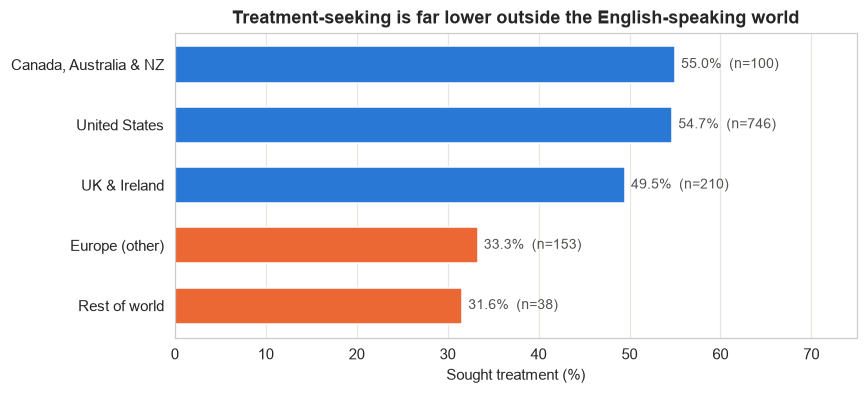

Region vs treatment: chi2 = 29.6, p = 5.87e-06


In [14]:
r = d.groupby("region").treated.agg(n="size", k="sum")
r["rate"] = (r.k / r.n * 100).round(1)
r = r.sort_values("rate")

fig, ax = plt.subplots(figsize=(8, 3.6))
bars = ax.barh(r.index, r.rate, color=[ORANGE if v < 40 else BLUE for v in r.rate], height=0.6)
ax.bar_label(bars, labels=[f"{v:.1f}%  (n={n})" for v, n in zip(r.rate, r.n)],
             padding=4, fontsize=9, color="#52514e")
ax.set_xlim(0, 75)
ax.set_xlabel("Sought treatment (%)")
ax.set_title("Treatment-seeking is far lower outside the English-speaking world")
ax.grid(axis="y", visible=False)

save(fig, "05_region_treatment")
plt.show()

from scipy import stats
chi2, p, dof, _ = stats.chi2_contingency(pd.crosstab(d.region, d.treated))
print(f"Region vs treatment: chi2 = {chi2:.1f}, p = {p:.2e}")

In [17]:
# CSV cannot store dtypes, so restore the orders defined in config (DQ-20)
df["no_employees"]   = pd.Categorical(df.no_employees,   categories=cfg.SIZE_ORDER,      ordered=True)
df["leave"]          = pd.Categorical(df.leave,          categories=cfg.LEAVE_ORDER,     ordered=True)
df["work_interfere"] = pd.Categorical(df.work_interfere, categories=cfg.INTERFERE_ORDER, ordered=True)
df["age_group"]      = pd.Categorical(df.age_group,      categories=cfg.AGE_LABELS,      ordered=True)
print(df.no_employees.cat.categories.tolist())

['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']


## 4. What employers provide — and whether anyone knows

These six questions ask about "your employer", so this section uses **employees
only (n = 1,088)**; self-employed respondents are excluded (DQ-14).

saved 06_benefits_by_size.png


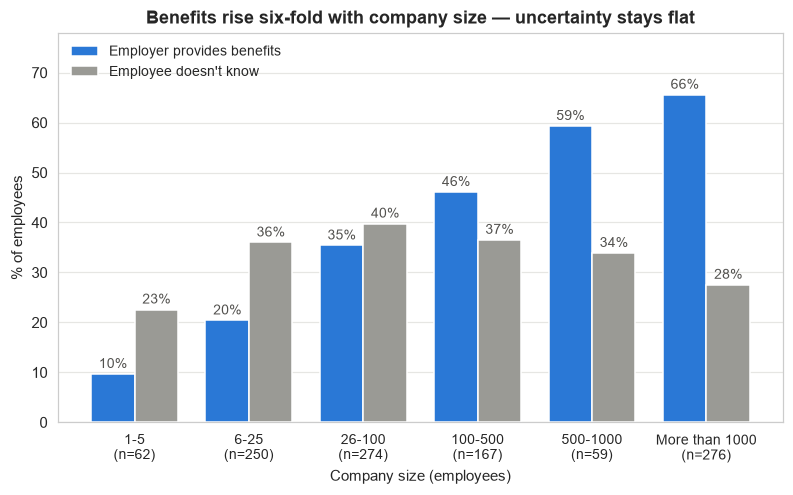

,n,benefits_yes,dont_know
no_employees,,,
1-5,62,9.7,22.6
6-25,250,20.4,36.0
26-100,274,35.4,39.8
100-500,167,46.1,36.5
500-1000,59,59.3,33.9
More than 1000,276,65.6,27.5


In [18]:
emp = df[df.employment_type == "Employee"].copy()
emp["treated"] = emp.treatment.eq("Yes")

size = emp.groupby("no_employees", observed=True).agg(
    n=("treatment", "size"),
    benefits_yes=("benefits", lambda s: (s == "Yes").mean() * 100),
    dont_know=("benefits", lambda s: (s == "Don't know").mean() * 100),
)

x = np.arange(len(size)); w = 0.38
fig, ax = plt.subplots(figsize=(8.5, 4.6))
b1 = ax.bar(x - w/2, size.benefits_yes, w, color=BLUE, label="Employer provides benefits")
b2 = ax.bar(x + w/2, size.dont_know, w, color=GREY, label="Employee doesn't know")
ax.bar_label(b1, fmt="%.0f%%", padding=2, fontsize=9, color="#52514e")
ax.bar_label(b2, fmt="%.0f%%", padding=2, fontsize=9, color="#52514e")

ax.set_xticks(x, [f"{i}\n(n={n})" for i, n in zip(size.index, size.n)], fontsize=9)
ax.set_ylim(0, 78)
ax.set_ylabel("% of employees")
ax.set_xlabel("Company size (employees)")
ax.set_title("Benefits rise six-fold with company size — uncertainty stays flat")
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, fontsize=9)
save(fig, "06_benefits_by_size")
plt.show()
size.round(1)

saved 07_uncertainty_gradient.png


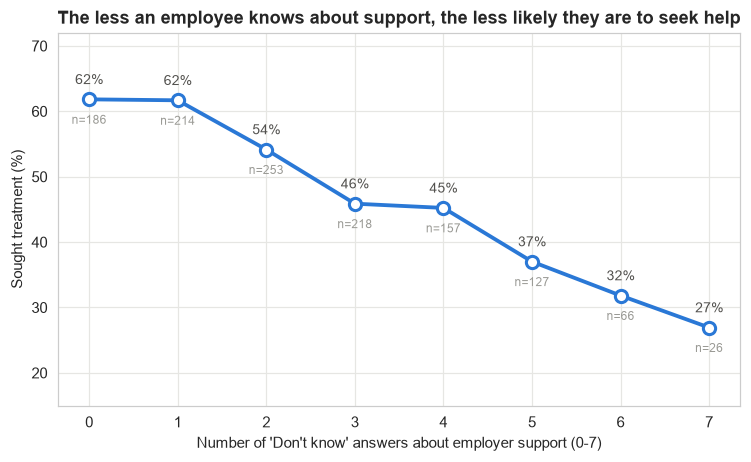

In [19]:
u = df.assign(treated=df.treatment.eq("Yes")).groupby("uncertainty_score").agg(
    n=("treated", "size"), rate=("treated", lambda s: s.mean() * 100))

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(u.index, u.rate, color=BLUE, lw=2.5, marker="o", markersize=8,
        markerfacecolor="white", markeredgewidth=2)
for xi, (rate, n) in enumerate(zip(u.rate, u.n)):
    ax.annotate(f"{rate:.0f}%", (xi, rate), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=9, color="#52514e")
    ax.annotate(f"n={n}", (xi, rate), textcoords="offset points",
                xytext=(0, -16), ha="center", fontsize=8, color="#9a9a95")

ax.set_ylim(15, 72)
ax.set_xlabel("Number of 'Don't know' answers about employer support (0-7)")
ax.set_ylabel("Sought treatment (%)")
ax.set_title("The less an employee knows about support, the less likely they are to seek help")
save(fig, "07_uncertainty_gradient")
plt.show()

### 4.1 Does more employer support keep raising treatment-seeking?

`support_score` (0-6) counts what the employer actually provides: benefits, known
care options, a wellness programme, help resources, protected anonymity, and easy
medical leave. Employees only (n = 1,088).

saved 08_support_score.png


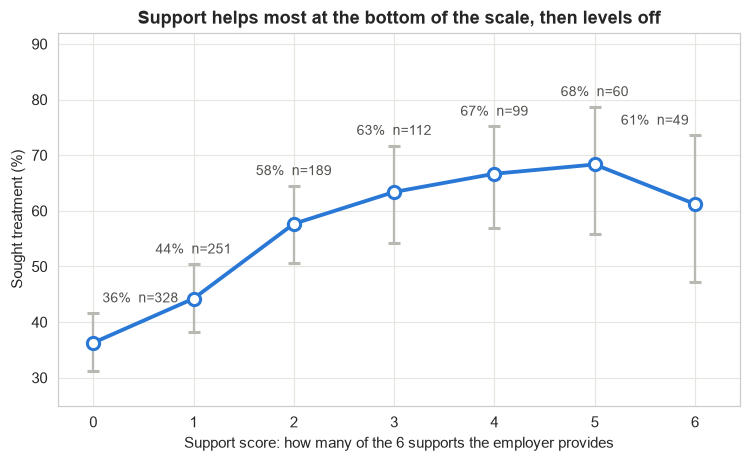

Spearman rho = 0.233, p = 7.49e-15


In [21]:
s = emp.groupby("support_score").treated.agg(n="size", k="sum")
s["rate"] = s.k / s.n * 100
s[["lo", "hi"]] = [wilson(k, n) for k, n in zip(s.k, s.n)]
s[["lo", "hi"]] *= 100

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.errorbar(s.index, s.rate, yerr=[s.rate - s.lo, s.hi - s.rate],
            fmt="o-", color=BLUE, lw=2.5, markersize=8, markerfacecolor="white",
            markeredgewidth=2, ecolor="#b9b9b4", elinewidth=1.5, capsize=4)
last = len(s) - 1
for xi, (hi, rate, n) in enumerate(zip(s.hi, s.rate, s.n)):
    ha, dx = "center", 0
    if xi == 0:
        ha, dx = "left", 6          # keep the first label off the y-axis
    elif xi == last:
        ha, dx = "right", -4        # keep the last one inside the plot
    ax.annotate(f"{rate:.0f}%  n={n}", (xi, hi), textcoords="offset points",
                xytext=(dx, 7), ha=ha, fontsize=9, color="#52514e")

ax.set_ylim(25, 92)
ax.set_xlim(-0.35, 6.45)
ax.set_xlabel("Support score: how many of the 6 supports the employer provides")
ax.set_ylabel("Sought treatment (%)")
ax.set_title("Support helps most at the bottom of the scale, then levels off")
save(fig, "08_support_score")
plt.show()

from scipy import stats
rho, p = stats.spearmanr(emp.support_score, emp.treated)
print(f"Spearman rho = {rho:.3f}, p = {p:.2e}")

## 5. Stigma: the mental vs physical gap

Four questions are asked twice — once about a mental health issue, once about a
physical one. Each respondent answers both, so the difference isolates attitude
towards mental health rather than towards disclosure in general.

saved 09_stigma_pairs.png


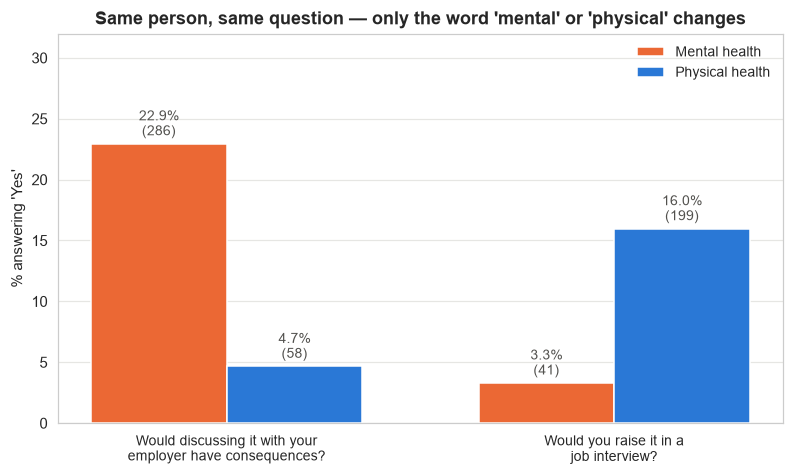

,question,kind,pct,n
0,Would discussing it with your\nemployer have c...,Mental health,22.9,286
1,Would discussing it with your\nemployer have c...,Physical health,4.7,58
2,Would you raise it in a\njob interview?,Mental health,3.3,41
3,Would you raise it in a\njob interview?,Physical health,16.0,199


In [22]:
pairs = [
    ("Would discussing it with your\nemployer have consequences?",
     "mental_health_consequence", "phys_health_consequence", "Yes"),
    ("Would you raise it in a\njob interview?",
     "mental_health_interview", "phys_health_interview", "Yes"),
]

rows = []
for label, m_col, p_col, answer in pairs:
    rows.append({"question": label, "kind": "Mental health",
                 "pct": (df[m_col] == answer).mean() * 100,
                 "n": (df[m_col] == answer).sum()})
    rows.append({"question": label, "kind": "Physical health",
                 "pct": (df[p_col] == answer).mean() * 100,
                 "n": (df[p_col] == answer).sum()})
stig = pd.DataFrame(rows)

x = np.arange(len(pairs)); w = 0.35
fig, ax = plt.subplots(figsize=(8.5, 4.6))
b1 = ax.bar(x - w/2, stig[stig.kind == "Mental health"].pct, w, color=ORANGE, label="Mental health")
b2 = ax.bar(x + w/2, stig[stig.kind == "Physical health"].pct, w, color=BLUE, label="Physical health")
ax.bar_label(b1, labels=[f"{v:.1f}%\n({n})" for v, n in zip(stig[stig.kind=='Mental health'].pct,
                                                           stig[stig.kind=='Mental health'].n)],
             padding=3, fontsize=9, color="#52514e")
ax.bar_label(b2, labels=[f"{v:.1f}%\n({n})" for v, n in zip(stig[stig.kind=='Physical health'].pct,
                                                            stig[stig.kind=='Physical health'].n)],
             padding=3, fontsize=9, color="#52514e")

ax.set_xticks(x, [p[0] for p in pairs], fontsize=9)
ax.set_ylim(0, 32)
ax.set_ylabel("% answering 'Yes'")
ax.set_title("Same person, same question — only the word 'mental' or 'physical' changes")
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, fontsize=9)
save(fig, "09_stigma_pairs")
plt.show()
stig.round(1)

In [23]:
print("Would discuss with...      Yes     Some     No")
for col in ["coworkers", "supervisor"]:
    v = df[col].value_counts(normalize=True).mul(100)
    print(f"{col:<22}{v.get('Yes',0):7.1f}{v.get('Some of them',0):9.1f}{v.get('No',0):8.1f}")

print("\nEmployer treats mental = physical?",
      df.mental_vs_physical.value_counts(normalize=True).mul(100).round(1).to_dict())

obs = df.assign(treated=df.treatment.eq("Yes")).groupby("obs_consequence").treated.agg(n="size", rate="mean")
obs["rate"] = (obs["rate"] * 100).round(1)
print("\nSeen a colleague suffer consequences:\n", obs)

Would discuss with...      Yes     Some     No
coworkers                17.8     61.6    20.6
supervisor               41.1     27.8    31.1

Employer treats mental = physical? {"Don't know": 46.0, 'Yes': 27.1, 'No': 26.9}

Seen a colleague suffer consequences:
                     n  rate
obs_consequence            
No               1067  47.3
Yes               180  69.4


## 6. What predicts treatment-seeking? (brief question 2)

Leakage rule (DQ-26): `work_interfere`, `has_condition` and `interfere_score` are
excluded from every model below — each one encodes "this person has a condition",
which is most of the answer.

Step 1: rank each candidate on its own using Cramer's V (association strength,
0 = none, 1 = perfect). Chi-square p-values say whether an effect is real;
Cramer's V says how big it is.

saved 10_association_ranking.png


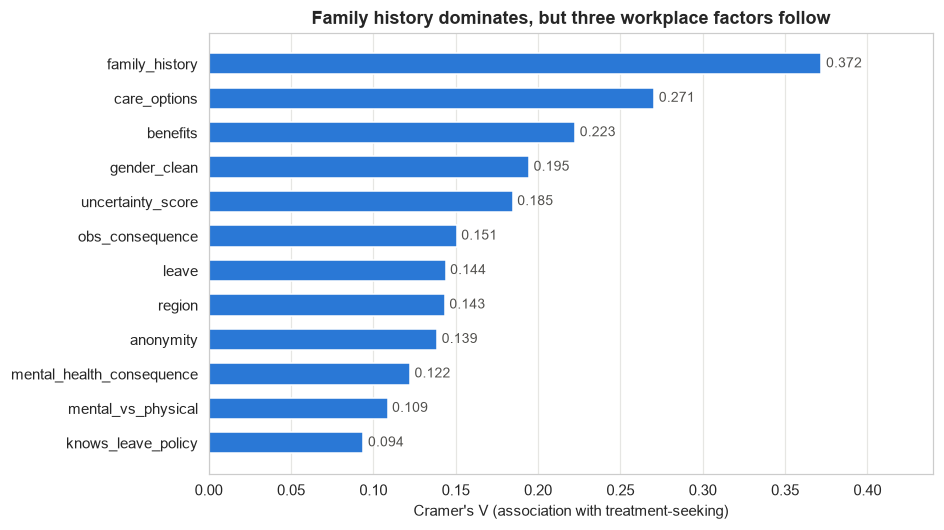

,factor,cramers_v,p
0,family_history,0.372,0.000
1,care_options,0.271,0.000
2,benefits,0.223,0.000
3,gender_clean,0.195,0.000
4,uncertainty_score,0.185,0.000
5,obs_consequence,0.151,0.000
6,leave,0.144,0.000
7,region,0.143,0.000
8,anonymity,0.139,0.000
9,mental_health_consequence,0.122,0.000


In [24]:
from scipy import stats

def cramers_v(a, b):
    """Association strength between two categorical variables, bias-corrected."""
    ct = pd.crosstab(a, b)
    chi2 = stats.chi2_contingency(ct)[0]
    n = ct.values.sum()
    r, k = ct.shape
    phi2 = chi2 / n
    phi2c = max(0, phi2 - (k-1)*(r-1)/(n-1))          # bias correction
    rc = r - ((r-1)**2)/(n-1)
    kc = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2c / max(1e-12, min(kc-1, rc-1)))

candidates = [
    "family_history", "gender_clean", "age_group", "region",
    "care_options", "benefits", "anonymity", "seek_help", "wellness_program",
    "leave", "knows_leave_policy", "uncertainty_score",
    "obs_consequence", "mental_vs_physical", "mental_health_consequence",
    "mental_health_interview", "coworkers", "supervisor",
    "no_employees", "remote_work", "tech_company", "employment_type", "survey_wave",
]

d = df.assign(treated=df.treatment.eq("Yes"))
assoc = pd.DataFrame(
    [{"factor": c,
      "cramers_v": cramers_v(d[c].astype(str), d.treated),
      "p": stats.chi2_contingency(pd.crosstab(d[c].astype(str), d.treated))[1]}
     for c in candidates]
).sort_values("cramers_v", ascending=False).reset_index(drop=True)

top = assoc.head(12)
fig, ax = plt.subplots(figsize=(8.5, 5.2))
colours = [BLUE if p < 0.05 else GREY for p in top.p]
bars = ax.barh(top.factor[::-1], top.cramers_v[::-1], color=colours[::-1], height=0.62)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9, color="#52514e")
ax.set_xlim(0, 0.44)
ax.set_xlabel("Cramer's V (association with treatment-seeking)")
ax.set_title("Family history dominates, but three workplace factors follow")
ax.grid(axis="y", visible=False)
save(fig, "10_association_ranking")
plt.show()
assoc.round(3)

### 6.1 Predicting treatment-seeking

Logistic regression, chosen over a tree or forest because we want to *read* the
coefficients, not just score predictions. Categorical features are one-hot encoded;
age and uncertainty_score are standardised.

Two models are fitted on purpose:
- **Honest** — obeys the DQ-26 leakage rule.
- **Leaky** — adds `work_interfere` and `has_condition`, which encode the answer.

The gap between them is the demonstration.

In [25]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

y = df.treatment.eq("Yes").astype(int)

CAT = ["family_history", "gender_clean", "age_group", "region", "care_options", "benefits",
       "anonymity", "seek_help", "wellness_program", "leave", "obs_consequence",
       "mental_vs_physical", "mental_health_consequence", "coworkers", "supervisor",
       "no_employees", "remote_work", "tech_company", "employment_type"]
NUM = ["age", "uncertainty_score"]

def build_model(cat_cols, num_cols):
    pre = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols),
        ("num", StandardScaler(), num_cols),
    ])
    return Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=2000))])

# ---- honest model (DQ-26 respected) ----
X = df[CAT + NUM]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
honest = build_model(CAT, NUM).fit(Xtr, ytr)
pred = honest.predict(Xte)
prob = honest.predict_proba(Xte)[:, 1]

# ---- leaky model (deliberately wrong) ----
CAT_LEAK = CAT + ["work_interfere", "has_condition"]
XL = df[CAT_LEAK + NUM]
XLtr, XLte, yLtr, yLte = train_test_split(XL, y, test_size=0.25, random_state=42, stratify=y)
leaky = build_model(CAT_LEAK, NUM).fit(XLtr, yLtr)
predL = leaky.predict(XLte)
probL = leaky.predict_proba(XLte)[:, 1]

print(f"{'Model':<28}{'Accuracy':>10}{'ROC AUC':>10}")
print(f"{'Always guess majority':<28}{max(y.mean(), 1-y.mean()):>10.3f}{'-':>10}")
print(f"{'Honest (DQ-26 respected)':<28}{accuracy_score(yte, pred):>10.3f}{roc_auc_score(yte, prob):>10.3f}")
print(f"{'Leaky (rule broken)':<28}{accuracy_score(yLte, predL):>10.3f}{roc_auc_score(yLte, probL):>10.3f}")

cv = cross_val_score(build_model(CAT, NUM), X, y, cv=5)
print(f"\nHonest model, 5-fold CV accuracy: {cv.mean():.3f} (+/- {cv.std():.3f})")
print("\nConfusion matrix (honest, test set):\n", confusion_matrix(yte, pred))
print("\n", classification_report(yte, pred, digits=3))

Model                         Accuracy   ROC AUC
Always guess majority            0.505         -
Honest (DQ-26 respected)         0.740     0.785
Leaky (rule broken)              0.846     0.911


d:\Tanay Nagpal\Labmentrix Internship\Mental Health Survey\VS CODE\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [18] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)



Honest model, 5-fold CV accuracy: 0.698 (+/- 0.029)

Confusion matrix (honest, test set):
 [[114  40]
 [ 41 117]]

               precision    recall  f1-score   support

           0      0.735     0.740     0.738       154
           1      0.745     0.741     0.743       158

    accuracy                          0.740       312
   macro avg      0.740     0.740     0.740       312
weighted avg      0.740     0.740     0.740       312



saved 11_odds_ratios.png


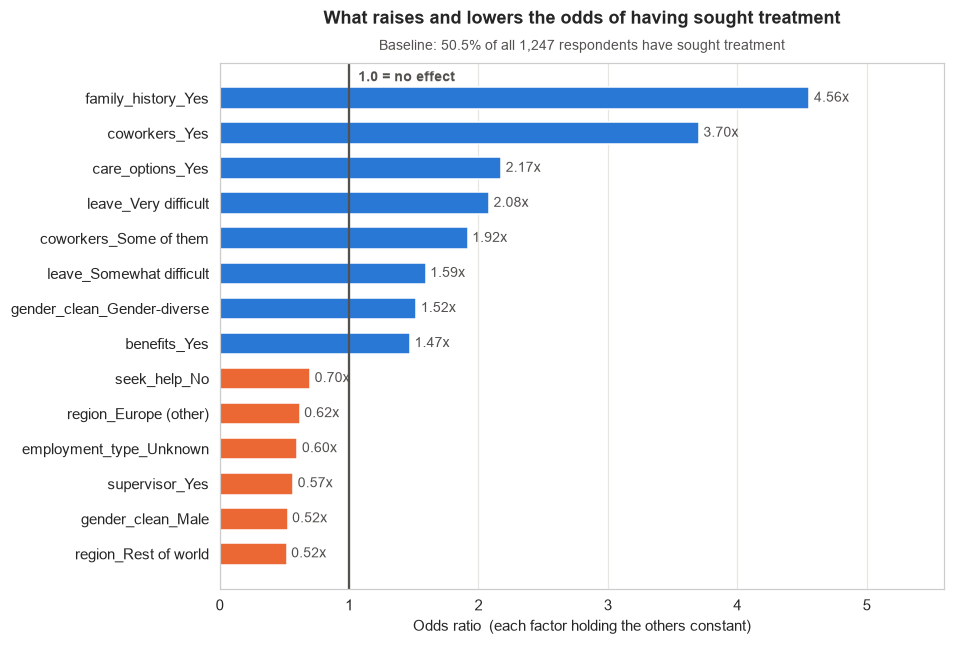

region_Rest of world           0.52
gender_clean_Male              0.52
supervisor_Yes                 0.57
employment_type_Unknown        0.60
region_Europe (other)          0.62
seek_help_No                   0.70
benefits_Yes                   1.47
gender_clean_Gender-diverse    1.52
leave_Somewhat difficult       1.59
coworkers_Some of them         1.92
leave_Very difficult           2.08
care_options_Yes               2.17
coworkers_Yes                  3.70
family_history_Yes             4.56
dtype: float64

In [28]:
names = [n.replace("cat__", "").replace("num__", "")
         for n in honest.named_steps["pre"].get_feature_names_out()]
odds = np.exp(pd.Series(honest.named_steps["clf"].coef_[0], index=names)).sort_values()
show = pd.concat([odds.head(6), odds.tail(8)])

fig, ax = plt.subplots(figsize=(8.5, 6.2))
colours = [ORANGE if v < 1 else BLUE for v in show]
bars = ax.barh(show.index, show.values, color=colours, height=0.62)
ax.bar_label(bars, fmt="%.2fx", padding=3, fontsize=9, color="#52514e")
ax.axvline(1, color="#52514e", lw=1.5)
ax.annotate("1.0 = no effect", xy=(1, 0.985), xycoords=("data", "axes fraction"),
            xytext=(6, 0), textcoords="offset points",
            color="#52514e", fontsize=9, fontweight="bold", ha="left", va="top")
ax.set_xlim(0, 5.6)
ax.set_xlabel("Odds ratio  (each factor holding the others constant)")
ax.set_title("What raises and lowers the odds of having sought treatment", pad=26)
ax.text(0.5, 1.02, f"Baseline: {y.mean():.1%} of all {len(df):,} respondents have sought treatment",
        transform=ax.transAxes, ha="center", va="bottom", fontsize=9, color="#52514e")
ax.grid(axis="y", visible=False)
save(fig, "11_odds_ratios")
plt.show()
show.round(2)

In [29]:
emp_ = df[df.employment_type == "Employee"]
cond_ = df[df.has_condition == "Yes"]
u_ = df.assign(t=df.treatment.eq("Yes")).groupby("uncertainty_score").t.mean() * 100
sz = emp_.groupby("no_employees", observed=True).benefits.apply(lambda s: (s == "Yes").mean() * 100)

findings = {
    "Respondents": f"{len(df):,}",
    "Report a condition": f"{(df.has_condition=='Yes').mean():.1%} ({(df.has_condition=='Yes').sum():,})",
    "Sought treatment": f"{(df.treatment=='Yes').mean():.1%}",
    "Condition but never treated": f"{((df.has_condition=='Yes') & (df.treatment=='No')).sum():,} "
                                  f"({((df.has_condition=='Yes') & (df.treatment=='No')).mean():.1%} of all)",
    "Treatment: women vs men": f"{(df[df.gender_clean=='Female'].treatment=='Yes').mean():.1%} vs "
                               f"{(df[df.gender_clean=='Male'].treatment=='Yes').mean():.1%}",
    "Treatment: US vs Europe (other)": f"{(df[df.region=='United States'].treatment=='Yes').mean():.1%} vs "
                                       f"{(df[df.region=='Europe (other)'].treatment=='Yes').mean():.1%}",
    "Benefits: smallest vs largest firm": f"{sz.iloc[0]:.1f}% vs {sz.iloc[-1]:.1f}%",
    "Treatment at 0 vs 7 'don't knows'": f"{u_.iloc[0]:.1f}% vs {u_.iloc[-1]:.1f}%",
    "Fear consequences: mental vs physical": f"{(df.mental_health_consequence=='Yes').mean():.1%} vs "
                                             f"{(df.phys_health_consequence=='Yes').mean():.1%}",
    "Would raise in interview: mental vs physical": f"{(df.mental_health_interview=='Yes').mean():.1%} vs "
                                                    f"{(df.phys_health_interview=='Yes').mean():.1%}",
    "Model accuracy (CV) vs baseline": f"{cv.mean():.1%} vs {max(y.mean(), 1-y.mean()):.1%}",
}
summary = pd.DataFrame(findings.items(), columns=["Finding", "Value"])
summary.to_csv(cfg.PROJECT_ROOT / "reports" / "key_findings.csv", index=False)
summary

,Finding,Value
0,Respondents,"1,247"
1,Report a condition,79.1% (986)
2,Sought treatment,50.5%
3,Condition but never treated,360 (28.9% of all)
4,Treatment: women vs men,68.8% vs 45.5%
5,Treatment: US vs Europe (other),54.7% vs 33.3%
6,Benefits: smallest vs largest firm,9.7% vs 65.6%
7,Treatment at 0 vs 7 'don't knows',61.8% vs 26.9%
8,Fear consequences: mental vs physical,22.9% vs 4.7%
9,Would raise in interview: mental vs physical,3.3% vs 16.0%


## 7. Conclusions

**Answering the brief's two questions**

*1. Does mental health vary by location?* Yes, but the honest statement is about
treatment-seeking, not illness. Continental Europe sits at 33.3% against 54.7% in
the US (chi2 = 22.3, p = 2.3e-06). Country-level differences below n = 20 are not
reported: Australia's apparent 61.9% carries a confidence interval of 40.9-79.2%.

*2. What are the strongest predictors?* Family history dominates (odds 4.56x,
Cramer's V 0.372) and no employer can change it. Among factors an employer does
control, **knowing your care options** is strongest (2.17x), followed by benefits
being provided (1.47x). Being male lowers the odds to 0.52x.

**Three findings worth acting on**

1. **360 respondents (28.9%) have a condition and have never sought treatment.**
   Within that group, the split between those who got help and those who did not is
   associated with employer support, not with company size, remote work, or sector.

2. **Uncertainty behaves like a barrier.** Treatment-seeking falls from 61.8% to
   26.9% as the number of "don't know" answers about employer support rises from 0
   to 7 — monotonically, across every step.

3. **Provision without communication is wasted.** Benefits provision rises 6.8x with
   company size (9.7% to 65.6%), but the share of employees who do not know whether
   benefits exist never falls below 22.6%. At 1000+ employee firms, 65.6% provide
   benefits and 27.5% of employees do not know.

**What the data cannot tell us**

- **Direction.** This is a cross-sectional survey. Better support may cause more
  treatment-seeking, or supportive firms may attract people already in treatment.
- **Illness vs help-seeking.** `treatment` measures having sought treatment (DQ-25).
- **Generalisability.** 79% male, 82% tech companies, 60% US, all volunteers
  recruited through a mental-health advocacy organisation (DQ-27). Every figure
  describes these 1,247 respondents, not the tech workforce.
- **Leakage demonstrated.** Adding `work_interfere` lifts accuracy from 74.0% to
  84.6%, which is why it is excluded (DQ-26).